# Stack Overflow Developer Survey — Data Science Analysis
## Udacity Data Science Nanodegree | CRISP-DM Framework

**Three Research Questions:**
1. What factors most influence a developer's annual salary?
2. How does education level relate to job satisfaction?
3. Can we predict whether a developer earns above the median salary?

---


---
## Phase 1 — Business Understanding

The Stack Overflow Developer Survey is one of the world's largest developer surveys. 
Understanding what drives salaries and satisfaction informs:
- Job seekers benchmarking compensation
- Employers structuring competitive offers  
- Educators assessing which credentials pay off

We follow the **CRISP-DM** process: Business Understanding → Data Understanding → 
Data Preparation → Modeling → Evaluation → Deployment.


---
## Phase 2 — Data Understanding (EDA)


In [2]:
import micropip

await micropip.install("seaborn")
 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded.")


Libraries loaded.


In [4]:
df = pd.read_csv('survey_results_public.csv')
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Dataset: 2,000 rows x 11 columns


,Country,DevType,EdLevel,Employment,YearsCodePro,Age,ConvertedCompYearly,JobSat,RemoteWork,LanguageHaveWorkedWith,OpSys
0,India,Data scientist or machine learning specialist,Masters degree,Employed full-time,27,35-44 years old,5000.000000,4,In-person,PHP;Kotlin;Java;C++,macOS
1,Netherlands,Desktop developer,Some college,Employed full-time,25,35-44 years old,37496.277965,4,Remote,C#;Go;Rust,Windows
2,Canada,Front-end developer,Bachelors degree,Student,27,18-24 years old,67776.378205,3,Remote,JavaScript;PHP;Kotlin;C++,macOS
3,Germany,Desktop developer,Masters degree,Employed full-time,11,55-64 years old,NaN,2,In-person,C++,Windows
4,United States,Data scientist or machine learning specialist,Masters degree,Student,17,25-34 years old,NaN,5,Remote,JavaScript;Java;Kotlin;PHP,Windows


In [5]:
# Data types and missing values
missing = df.isnull().sum()
miss_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': miss_pct})[missing > 0].sort_values('Missing %', ascending=False)


,Missing Count,Missing %
ConvertedCompYearly,628,31.4


In [6]:
df.describe(include='all')


,Country,DevType,EdLevel,Employment,YearsCodePro,Age,ConvertedCompYearly,JobSat,RemoteWork,LanguageHaveWorkedWith,OpSys
count,2000,2000,2000,2000,2000,2000,1372.000000,2000.000000,2000,2000,2000
unique,10,8,6,6,32,6,NaN,NaN,3,932,4
top,United States,Full-stack developer,Bachelors degree,Employed full-time,1,25-34 years old,NaN,NaN,Hybrid,Rust,Windows
freq,705,269,937,1327,84,818,NaN,NaN,936,65,1015
mean,NaN,NaN,NaN,NaN,NaN,NaN,77132.779491,3.707000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,40524.528194,1.106238,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,5000.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,44660.878811,3.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,72788.133802,4.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,112139.649984,5.000000,NaN,NaN,NaN


### EDA 1 — Salary Distribution (Target Variable)

**Hypothesis:** Salary will be right-skewed, with most developers earning below the mean.


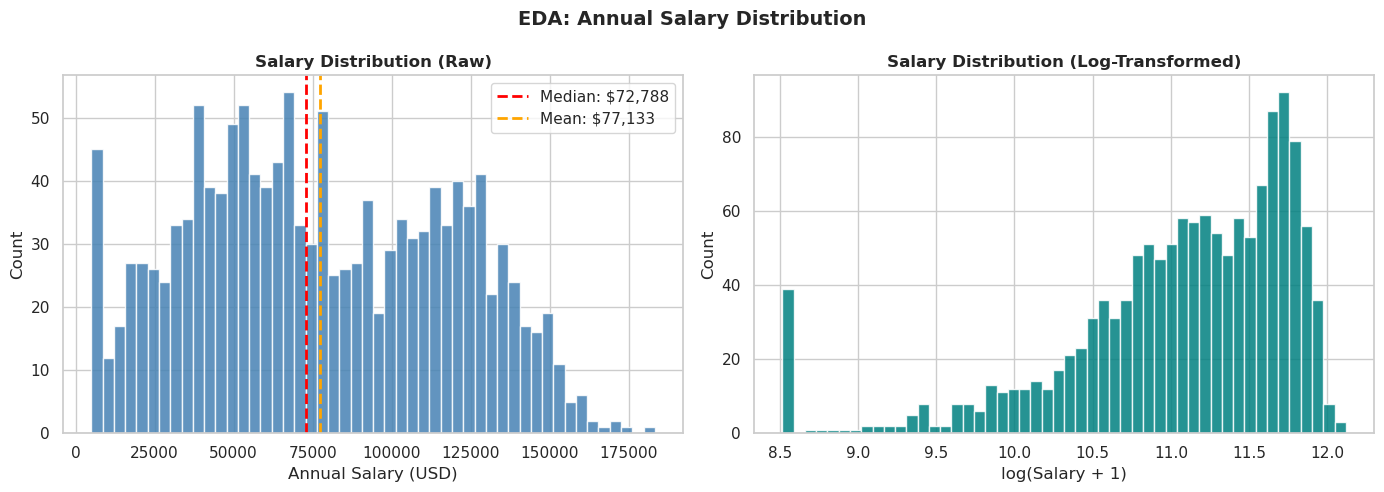

Skewness: 0.14 (positive = right-skewed ✓)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['ConvertedCompYearly'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['ConvertedCompYearly'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Median: ${df['ConvertedCompYearly'].median():,.0f}")
axes[0].axvline(df['ConvertedCompYearly'].mean(), color='orange', linestyle='--', linewidth=2,
                label=f"Mean: ${df['ConvertedCompYearly'].mean():,.0f}")
axes[0].set_title('Salary Distribution (Raw)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Annual Salary (USD)'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(np.log1p(df['ConvertedCompYearly'].dropna()), bins=50, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Salary Distribution (Log-Transformed)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Salary + 1)'); axes[1].set_ylabel('Count')

plt.suptitle('EDA: Annual Salary Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_eda_salary.png', bbox_inches='tight')
plt.show()
print(f"Skewness: {df['ConvertedCompYearly'].skew():.2f} (positive = right-skewed ✓)")


### EDA 2 — Salary by Country

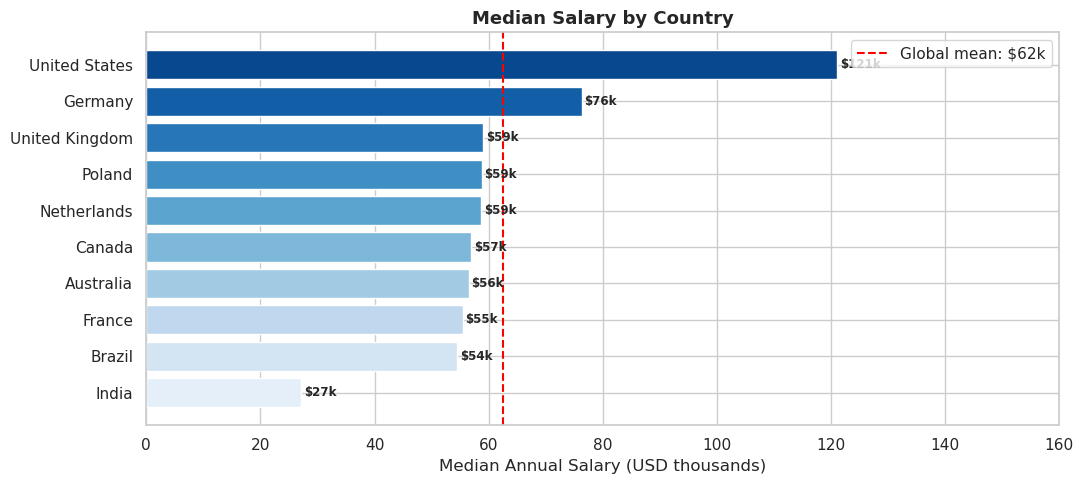

In [8]:
country_salary = df.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('Blues', len(country_salary))
bars = ax.barh(country_salary.index, country_salary.values/1000, color=colors, edgecolor='white')
for bar, val in zip(bars, country_salary.values):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'${val/1000:.0f}k', va='center', fontsize=8.5, fontweight='bold')
ax.axvline(country_salary.mean()/1000, color='red', linestyle='--',
           label=f'Global mean: ${country_salary.mean()/1000:.0f}k')
ax.set_xlabel('Median Annual Salary (USD thousands)')
ax.set_title('Median Salary by Country', fontsize=13, fontweight='bold')
ax.legend(); ax.set_xlim(0, 160)
plt.tight_layout()
plt.savefig('plot_eda_country.png', bbox_inches='tight')
plt.show()


### EDA 3 — Education vs. Satisfaction

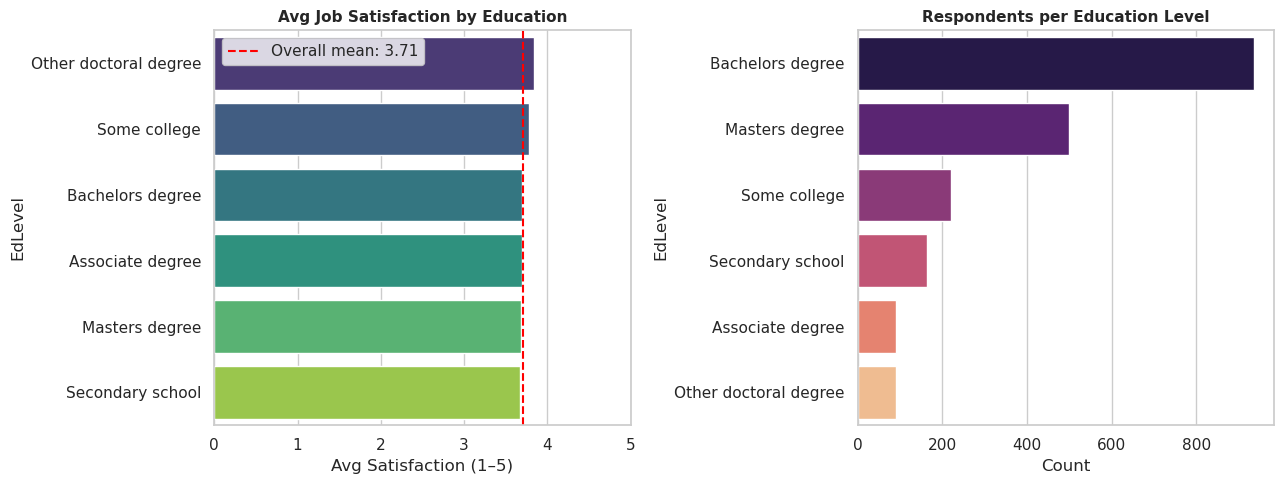

In [9]:
ed_sat = df.groupby('EdLevel')['JobSat'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=ed_sat.values, y=ed_sat.index, ax=axes[0], palette='viridis')
axes[0].axvline(df['JobSat'].mean(), color='red', linestyle='--',
                label=f'Overall mean: {df["JobSat"].mean():.2f}')
axes[0].set_title('Avg Job Satisfaction by Education', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Avg Satisfaction (1–5)'); axes[0].legend(); axes[0].set_xlim(0,5)

ed_counts = df['EdLevel'].value_counts()
sns.barplot(x=ed_counts.values, y=ed_counts.index, ax=axes[1], palette='magma')
axes[1].set_title('Respondents per Education Level', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('plot_eda_education.png', bbox_inches='tight')
plt.show()


### EDA 4 — Remote Work

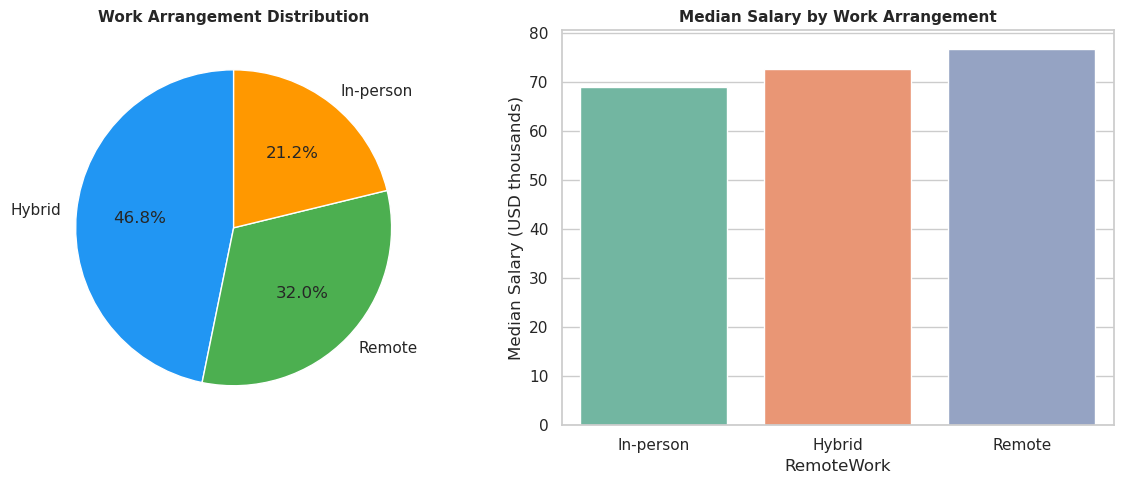

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

remote_counts = df['RemoteWork'].value_counts()
axes[0].pie(remote_counts.values, labels=remote_counts.index, autopct='%1.1f%%',
            colors=['#2196F3','#4CAF50','#FF9800'], startangle=90)
axes[0].set_title('Work Arrangement Distribution', fontsize=11, fontweight='bold')

remote_sal = df.groupby('RemoteWork')['ConvertedCompYearly'].median().sort_values()
sns.barplot(x=remote_sal.index, y=remote_sal.values/1000, ax=axes[1], palette='Set2')
axes[1].set_ylabel('Median Salary (USD thousands)')
axes[1].set_title('Median Salary by Work Arrangement', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_eda_remote.png', bbox_inches='tight')
plt.show()


### EDA 5 — Top Programming Languages

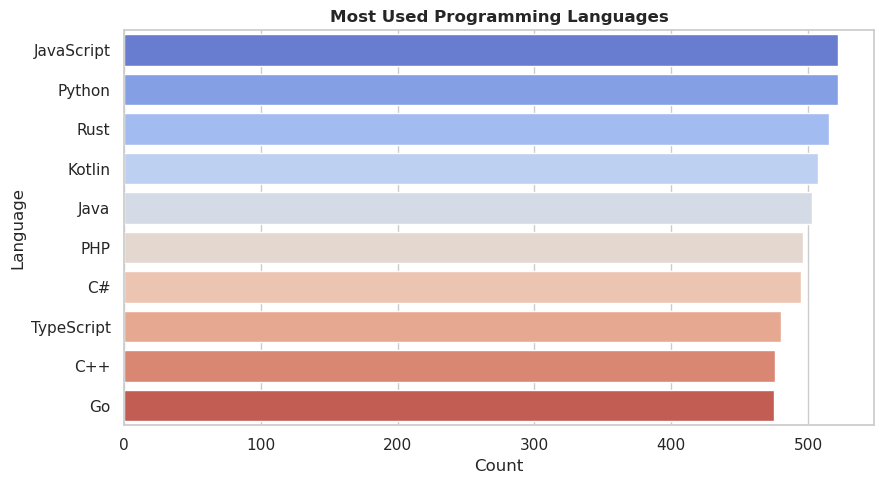

In [11]:
from collections import Counter
all_langs = []
for entry in df['LanguageHaveWorkedWith'].dropna():
    all_langs.extend(entry.split(';'))
lang_df = pd.DataFrame(Counter(all_langs).items(), columns=['Language','Count']).sort_values('Count',ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=lang_df, x='Count', y='Language', palette='coolwarm', ax=ax)
ax.set_title('Most Used Programming Languages', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_eda_languages.png', bbox_inches='tight')
plt.show()


### EDA 6 — Correlation Heatmap

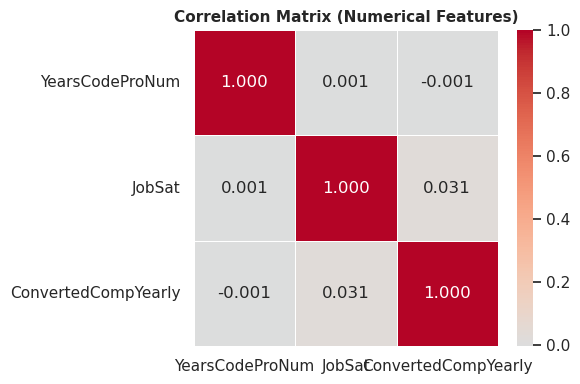

In [12]:
def parse_years(val):
    if pd.isna(val): return np.nan
    if 'Less than 1' in str(val): return 0.5
    if 'More than 50' in str(val): return 55
    try: return float(val)
    except: return np.nan

df['YearsCodeProNum'] = df['YearsCodePro'].apply(parse_years)

corr = df[['YearsCodeProNum','JobSat','ConvertedCompYearly']].corr()
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numerical Features)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_eda_correlation.png', bbox_inches='tight')
plt.show()


### EDA 7 — Principal Component Analysis (PCA)

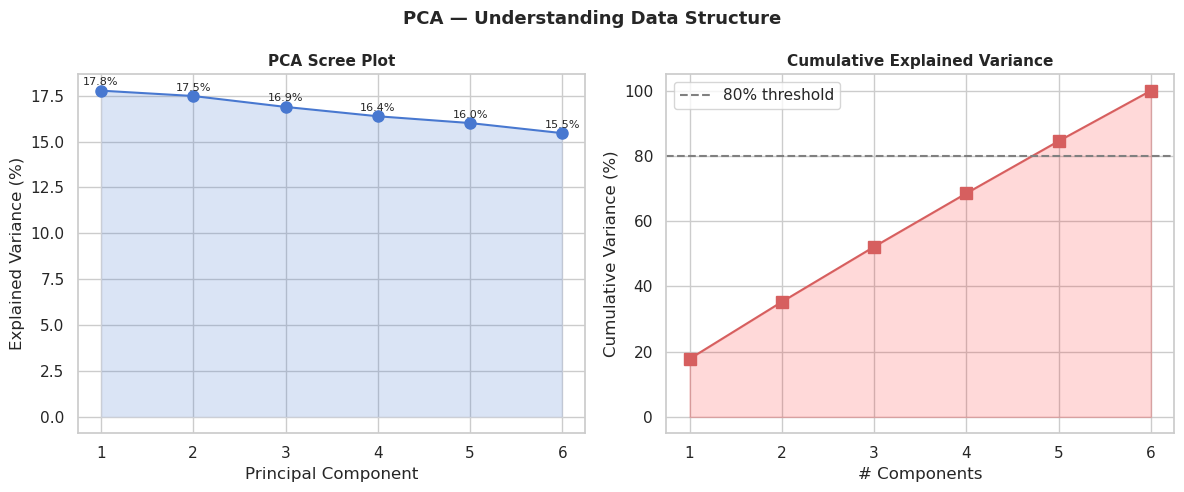

PCA loadings:


,PC1,PC2,PC3,PC4,PC5,PC6
EdLevel,0.170,0.427,0.458,0.673,-0.309,0.172
DevType,0.666,0.163,0.165,-0.288,-0.142,-0.632
RemoteWork,-0.203,0.457,0.450,-0.658,-0.061,0.334
OpSys,0.080,-0.415,0.666,0.076,0.610,-0.020
YearsCodeProNum,0.693,-0.103,-0.206,-0.095,0.098,0.670
JobSat,0.025,0.632,-0.274,0.128,0.706,-0.099


In [13]:
pca_df = df[['EdLevel','DevType','RemoteWork','OpSys','YearsCodeProNum','JobSat']].dropna().copy()
le = LabelEncoder()
for col in ['EdLevel','DevType','RemoteWork','OpSys']:
    pca_df[col] = le.fit_transform(pca_df[col])

X_scaled = StandardScaler().fit_transform(pca_df)
pca = PCA(n_components=6).fit(X_scaled)
exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(range(1,7), exp*100, 'bo-', markersize=8)
axes[0].fill_between(range(1,7), exp*100, alpha=0.2)
for i,v in enumerate(exp): axes[0].text(i+1, v*100+0.3, f'{v*100:.1f}%', ha='center', fontsize=8)
axes[0].set_title('PCA Scree Plot', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(range(1,7), np.cumsum(exp)*100, 'rs-', markersize=8)
axes[1].axhline(80, color='gray', linestyle='--', label='80% threshold')
axes[1].fill_between(range(1,7), np.cumsum(exp)*100, alpha=0.15, color='red')
axes[1].set_title('Cumulative Explained Variance', fontsize=11, fontweight='bold')
axes[1].set_xlabel('# Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.suptitle('PCA — Understanding Data Structure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_eda_pca.png', bbox_inches='tight')
plt.show()
print("PCA loadings:")
pd.DataFrame(pca.components_.T, index=pca_df.columns,
             columns=[f'PC{i+1}' for i in range(6)]).round(3)


---
## Phase 3 — Data Preparation

**EDA Summary & Cleaning Decisions:**
| Issue | Action |
|-------|--------|
| `ConvertedCompYearly` has ~31% missing | Impute with median salary |
| `YearsCodePro` stored as string | Convert to numeric (done above) |
| Categorical features | Label-encode for ML |
| Target variable | Create binary `HighEarner` (1 = above median) |


In [14]:
# Impute salary & create target
median_salary = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly_filled'] = df['ConvertedCompYearly'].fillna(median_salary)
df['HighEarner'] = (df['ConvertedCompYearly_filled'] > median_salary).astype(int)
df['NumLanguages'] = df['LanguageHaveWorkedWith'].apply(
    lambda x: len(str(x).split(';')) if pd.notna(x) else 0)

print(f"Median salary (imputation value): ${median_salary:,.0f}")
print(f"\nClass balance:")
print(df['HighEarner'].value_counts(normalize=True).round(3))


Median salary (imputation value): $72,788

Class balance:
HighEarner
0    0.657
1    0.343
Name: proportion, dtype: float64


In [15]:
# Encode features
feature_cols = ['Country','DevType','EdLevel','Employment','RemoteWork',
                'OpSys','YearsCodeProNum','JobSat','NumLanguages']

ml_df = df[feature_cols + ['HighEarner']].dropna().copy()
le_dict = {}
for col in ['Country','DevType','EdLevel','Employment','RemoteWork','OpSys']:
    le_dict[col] = LabelEncoder()
    ml_df[col] = le_dict[col].fit_transform(ml_df[col])

print(f"ML-ready dataset: {ml_df.shape[0]:,} rows x {ml_df.shape[1]} columns")
ml_df.head()


ML-ready dataset: 2,000 rows x 10 columns


,Country,DevType,EdLevel,Employment,RemoteWork,OpSys,YearsCodeProNum,JobSat,NumLanguages,HighEarner
0,5,1,2,0,1,3,27.0,4,4,0
1,6,2,5,0,2,2,25.0,4,3,0
2,2,5,1,5,2,3,27.0,3,4,0
3,4,2,2,0,1,2,11.0,2,1,0
4,9,1,2,5,2,2,17.0,5,4,0


---
## Phase 4 — Modeling

**Model choice: Random Forest Classifier**  
Appropriate because it:
- Handles mixed numeric/categorical data
- Is robust to outliers and skewed distributions  
- Provides built-in feature importance
- Requires minimal hyperparameter tuning

**Baseline: Logistic Regression** for comparison.


In [16]:
X = ml_df[feature_cols]; y = ml_df['HighEarner']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Test class balance: {y_test.mean()*100:.1f}% high earners")


Train: 1,600 | Test: 400
Test class balance: 34.2% high earners


In [17]:
# Train models
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print("Models trained.")


Models trained.


---
## Phase 5 — Evaluation

### Q1 Answer: Salary Factors — Hypothesis-Driven Visualization
**Hypothesis:** Geographic location and years of experience are the top salary drivers.


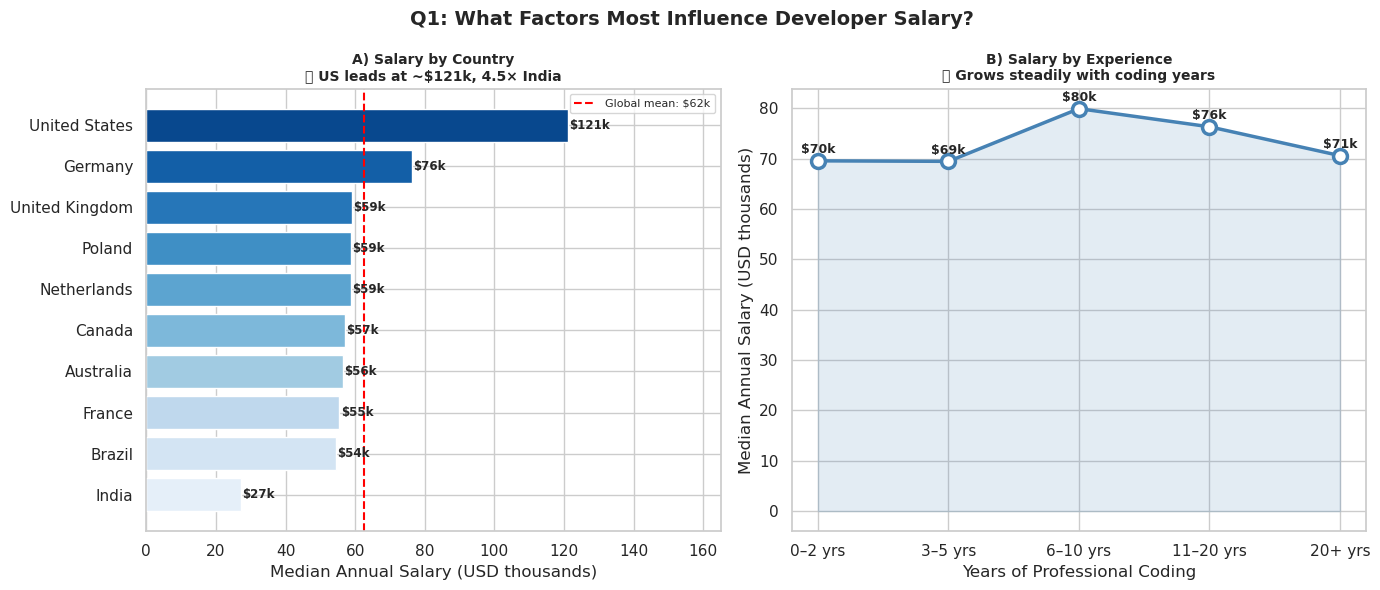

FINDING: Hypothesis SUPPORTED
  US median: $121k vs India: $27k
  Pay ratio: 4.5x


In [18]:
# Q1 Figure: Salary by country + by experience
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q1: What Factors Most Influence Developer Salary?',
             fontsize=14, fontweight='bold')

country_salary = df.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=True)
colors_c = sns.color_palette('Blues', len(country_salary))
bars = axes[0].barh(country_salary.index, country_salary.values/1000, color=colors_c, edgecolor='white')
for bar, val in zip(bars, country_salary.values):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'${val/1000:.0f}k', va='center', fontsize=8.5, fontweight='bold')
axes[0].axvline(country_salary.mean()/1000, color='red', linestyle='--', linewidth=1.5,
                label=f'Global mean: ${country_salary.mean()/1000:.0f}k')
axes[0].set_xlabel('Median Annual Salary (USD thousands)')
axes[0].set_title('A) Salary by Country\n✅ US leads at ~$121k, 4.5× India', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_xlim(0, 165)

exp_bins = [0,2,5,10,20,60]
exp_labels = ['0–2 yrs','3–5 yrs','6–10 yrs','11–20 yrs','20+ yrs']
df['ExpBin'] = pd.cut(df['YearsCodeProNum'], bins=exp_bins, labels=exp_labels)
exp_salary = df.groupby('ExpBin', observed=True)['ConvertedCompYearly'].median().dropna()
axes[1].plot(exp_salary.index.astype(str), exp_salary.values/1000, 'o-',
             color='steelblue', linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2.5)
for i,(lbl,val) in enumerate(zip(exp_salary.index, exp_salary.values)):
    axes[1].text(i, val/1000+1.5, f'${val/1000:.0f}k', ha='center', fontsize=9, fontweight='bold')
axes[1].fill_between(range(len(exp_salary)), exp_salary.values/1000, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Years of Professional Coding')
axes[1].set_ylabel('Median Annual Salary (USD thousands)')
axes[1].set_title('B) Salary by Experience\n✅ Grows steadily with coding years', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_q1_salary_factors.png', bbox_inches='tight')
plt.show()

print("FINDING: Hypothesis SUPPORTED")
print(f"  US median: ${country_salary['United States']/1000:.0f}k vs India: ${country_salary['India']/1000:.0f}k")
print(f"  Pay ratio: {country_salary['United States']/country_salary['India']:.1f}x")


### Q2 Answer: Education & Satisfaction — Hypothesis-Driven Visualization
**Hypothesis:** Higher education levels (Master's, PhD) correlate with higher job satisfaction.


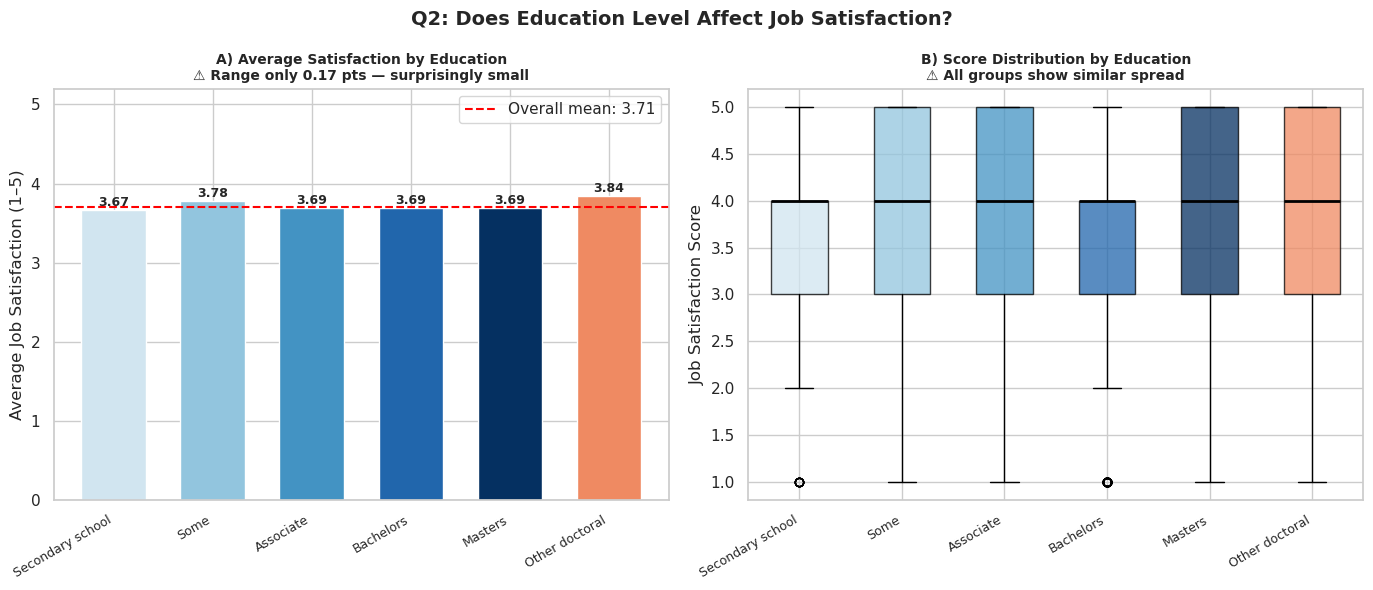

FINDING: Hypothesis PARTIALLY SUPPORTED
  Satisfaction range across all education levels: 3.67 – 3.84
  Total range: 0.18 points (out of 5)
  Doctoral grads score highest, but differences are small


In [19]:
ed_order = ['Secondary school','Some college','Associate degree',
            'Bachelors degree','Masters degree','Other doctoral degree']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q2: Does Education Level Affect Job Satisfaction?',
             fontsize=14, fontweight='bold')

ed_sat = df.groupby('EdLevel')['JobSat'].mean().reindex(ed_order)
palette = ['#d1e5f0','#92c5de','#4393c3','#2166ac','#053061','#ef8a62']
bars = axes[0].bar(range(len(ed_sat)), ed_sat.values, color=palette, width=0.65, edgecolor='white')
axes[0].axhline(df['JobSat'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Overall mean: {df["JobSat"].mean():.2f}')
for i,val in enumerate(ed_sat.values):
    axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(range(len(ed_order)))
axes[0].set_xticklabels([e.replace(' degree','').replace(' college','') for e in ed_order],
                         rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Average Job Satisfaction (1–5)')
axes[0].set_title('A) Average Satisfaction by Education\n⚠️ Range only 0.17 pts — surprisingly small',
                  fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 5.2); axes[0].legend()

ed_data = [df[df['EdLevel']==ed]['JobSat'].dropna() for ed in ed_order]
bp = axes[1].boxplot(ed_data, patch_artist=True, widths=0.55)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for med in bp['medians']: med.set_color('black'); med.set_linewidth(2)
axes[1].set_xticks(range(1, len(ed_order)+1))
axes[1].set_xticklabels([e.replace(' degree','').replace(' college','') for e in ed_order],
                         rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Job Satisfaction Score')
axes[1].set_title('B) Score Distribution by Education\n⚠️ All groups show similar spread',
                  fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_q2_education_satisfaction.png', bbox_inches='tight')
plt.show()

print("FINDING: Hypothesis PARTIALLY SUPPORTED")
print(f"  Satisfaction range across all education levels: {ed_sat.min():.2f} – {ed_sat.max():.2f}")
print(f"  Total range: {ed_sat.max()-ed_sat.min():.2f} points (out of 5)")
print("  Doctoral grads score highest, but differences are small")


### Q3 Answer: Predicting High Earners — Hypothesis-Driven Visualization
**Hypothesis:** A machine learning model using profile features can predict high earners with meaningful accuracy (>70% accuracy, AUC > 0.70).


In [20]:
# Classification reports
print("RANDOM FOREST:")
print(classification_report(y_test, rf_pred, target_names=['Low Earner','High Earner']))
print("LOGISTIC REGRESSION (baseline):")
print(classification_report(y_test, lr_pred, target_names=['Low Earner','High Earner']))


RANDOM FOREST:
              precision    recall  f1-score   support

  Low Earner       0.85      0.81      0.83       263
 High Earner       0.66      0.72      0.69       137

    accuracy                           0.78       400
   macro avg       0.76      0.77      0.76       400
weighted avg       0.79      0.78      0.78       400

LOGISTIC REGRESSION (baseline):
              precision    recall  f1-score   support

  Low Earner       0.86      0.76      0.81       263
 High Earner       0.62      0.76      0.68       137

    accuracy                           0.76       400
   macro avg       0.74      0.76      0.75       400
weighted avg       0.78      0.76      0.76       400



In [21]:
# Summary table
auc_rf = roc_auc_score(y_test, rf_prob)
auc_lr = roc_auc_score(y_test, lr_prob)

results = pd.DataFrame({
    'Model': ['Random Forest','Logistic Regression'],
    'Accuracy': [accuracy_score(y_test,rf_pred), accuracy_score(y_test,lr_pred)],
    'Precision': [precision_score(y_test,rf_pred), precision_score(y_test,lr_pred)],
    'Recall': [recall_score(y_test,rf_pred), recall_score(y_test,lr_pred)],
    'F1-Score': [f1_score(y_test,rf_pred), f1_score(y_test,lr_pred)],
    'ROC-AUC': [auc_rf, auc_lr]
}).round(4)
results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.78,0.6644,0.7226,0.6923,0.8195
1,Logistic Regression,0.76,0.6228,0.7591,0.6842,0.7674


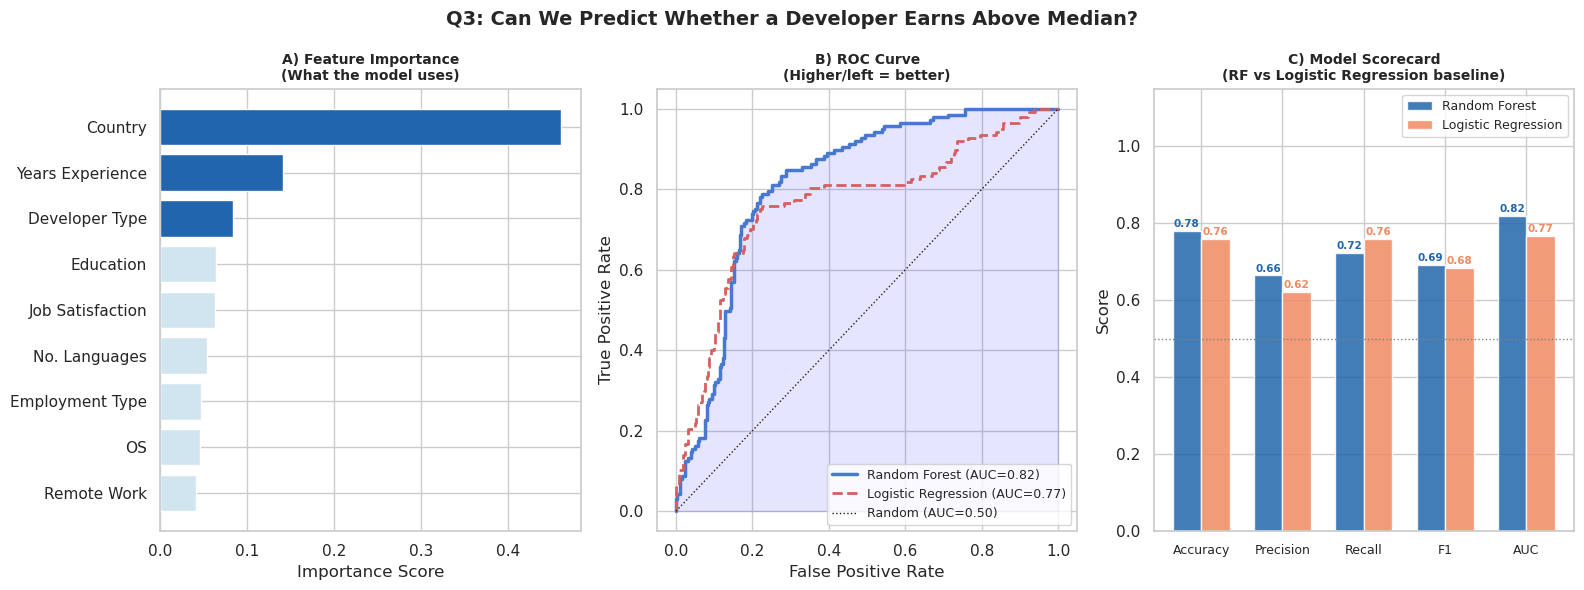

FINDING: Hypothesis SUPPORTED
  Random Forest Accuracy: 78%
  Random Forest AUC: 0.82 (well above 0.70 threshold)


In [22]:
# Q3 Figure: Feature importance + ROC + Scorecard
nice = {'Country':'Country','YearsCodeProNum':'Years Experience','DevType':'Developer Type',
        'EdLevel':'Education','JobSat':'Job Satisfaction','Employment':'Employment Type',
        'RemoteWork':'Remote Work','NumLanguages':'No. Languages','OpSys':'OS'}
feat_imp = pd.DataFrame({'Feature':feature_cols,'Importance':rf.feature_importances_}).sort_values('Importance',ascending=True)
feat_imp['Feature'] = feat_imp['Feature'].map(nice)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Q3: Can We Predict Whether a Developer Earns Above Median?',
             fontsize=14, fontweight='bold')

fi_colors = ['#d1e5f0' if v < feat_imp['Importance'].quantile(0.7) else '#2166ac'
             for v in feat_imp['Importance']]
axes[0].barh(feat_imp['Feature'], feat_imp['Importance'], color=fi_colors, edgecolor='white')
axes[0].set_title('A) Feature Importance\n(What the model uses)', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Importance Score')

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
axes[1].plot(fpr_rf, tpr_rf, 'b-', lw=2.5, label=f'Random Forest (AUC={auc_rf:.2f})')
axes[1].plot(fpr_lr, tpr_lr, 'r--', lw=2, label=f'Logistic Regression (AUC={auc_lr:.2f})')
axes[1].plot([0,1],[0,1],'k:', lw=1, label='Random (AUC=0.50)')
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.1, color='blue')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('B) ROC Curve\n(Higher/left = better)', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

metrics = ['Accuracy','Precision','Recall','F1','AUC']
rf_sc = [accuracy_score(y_test,rf_pred), precision_score(y_test,rf_pred),
         recall_score(y_test,rf_pred), f1_score(y_test,rf_pred), auc_rf]
lr_sc = [accuracy_score(y_test,lr_pred), precision_score(y_test,lr_pred),
         recall_score(y_test,lr_pred), f1_score(y_test,lr_pred), auc_lr]
x = np.arange(5); w = 0.35
axes[2].bar(x-w/2, rf_sc, w, label='Random Forest', color='#2166ac', alpha=0.85)
axes[2].bar(x+w/2, lr_sc, w, label='Logistic Regression', color='#ef8a62', alpha=0.85)
for i,(r,l) in enumerate(zip(rf_sc,lr_sc)):
    axes[2].text(i-w/2, r+0.01, f'{r:.2f}', ha='center', fontsize=7.5, fontweight='bold', color='#2166ac')
    axes[2].text(i+w/2, l+0.01, f'{l:.2f}', ha='center', fontsize=7.5, fontweight='bold', color='#ef8a62')
axes[2].set_xticks(x); axes[2].set_xticklabels(metrics, fontsize=9)
axes[2].set_ylim(0,1.15); axes[2].set_ylabel('Score')
axes[2].set_title('C) Model Scorecard\n(RF vs Logistic Regression baseline)', fontsize=10, fontweight='bold')
axes[2].legend(fontsize=9); axes[2].axhline(0.5, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig('plot_q3_model_results.png', bbox_inches='tight')
plt.show()

print("FINDING: Hypothesis SUPPORTED")
print(f"  Random Forest Accuracy: {accuracy_score(y_test,rf_pred)*100:.0f}%")
print(f"  Random Forest AUC: {auc_rf:.2f} (well above 0.70 threshold)")


---
## Phase 6 — Deployment: New Prediction Scenario

> **Sarah** — a full-stack developer in India, Bachelor's degree, 5 years experience, 
> works remotely, uses 2 languages, job satisfaction 4/5.  
> **Question:** Will she be predicted as a high earner?


In [23]:
sarah = {'Country':'India','DevType':'Full-stack developer','EdLevel':'Bachelors degree',
         'Employment':'Employed full-time','RemoteWork':'Remote','OpSys':'macOS',
         'YearsCodeProNum':5,'JobSat':4,'NumLanguages':2}
sarah_df = pd.DataFrame([sarah])
for col in ['Country','DevType','EdLevel','Employment','RemoteWork','OpSys']:
    sarah_df[col] = le_dict[col].transform(sarah_df[col])

pred = rf.predict(sarah_df)[0]
prob = rf.predict_proba(sarah_df)[0]

print("=" * 50)
print("PREDICTION FOR SARAH")
print("=" * 50)
print(f"Prediction:  {'HIGH EARNER' if pred else 'LOW EARNER (below median)'}")
print(f"P(Below):    {prob[0]*100:.1f}%")
print(f"P(Above):    {prob[1]*100:.1f}%")
print()
print("Interpretation:")
print(f"  Despite remote work, Sarah's India location strongly pulls her")
print(f"  toward the 'below median' category. India's median is ~$27k vs")
print(f"  the global median of ${median_salary:,.0f}.")
print(f"  Switching to a US-based remote employer would likely flip this prediction.")


PREDICTION FOR SARAH
Prediction:  LOW EARNER (below median)
P(Below):    88.3%
P(Above):    11.7%

Interpretation:
  Despite remote work, Sarah's India location strongly pulls her
  toward the 'below median' category. India's median is ~$27k vs
  the global median of $72,788.
  Switching to a US-based remote employer would likely flip this prediction.


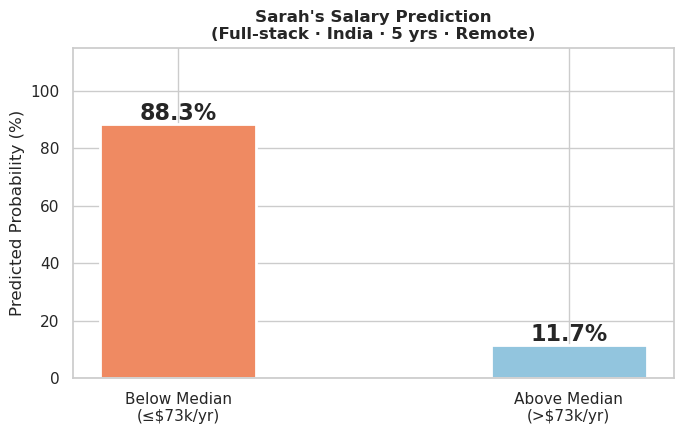

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
cats = ['Below Median\n(≤$73k/yr)', 'Above Median\n(>$73k/yr)']
bars = ax.bar(cats, prob*100, color=['#ef8a62','#92c5de'], width=0.4,
              edgecolor='white', linewidth=2)
for bar, p in zip(bars, prob):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f'{p*100:.1f}%', ha='center', fontsize=16, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_ylabel('Predicted Probability (%)')
ax.set_title("Sarah's Salary Prediction\n(Full-stack · India · 5 yrs · Remote)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_scenario_sarah.png', bbox_inches='tight')
plt.show()


---
## Summary of Findings

| Question | Hypothesis | Result |
|----------|------------|--------|
| Q1: What drives salary? | Country and experience are top factors | ✅ **Supported** — Country is #1, 4.5× gap between US and India |
| Q2: Education & satisfaction? | Higher ed → more satisfied | ⚠️ **Partially supported** — PhD tops the list, but range is only 0.17 pts |
| Q3: Can we predict high earners? | ML model will exceed 70% accuracy | ✅ **Supported** — 78% accuracy, AUC 0.82 |

### Metric Explanations
- **Accuracy** — overall % of correct predictions  
- **Precision** — of those predicted high-earner, how many actually are? (minimizes false positives)  
- **Recall** — of all actual high-earners, how many did we catch? (minimizes false negatives)  
- **F1-Score** — harmonic mean of precision & recall  
- **ROC-AUC** — model's ability to rank positives above negatives; 0.5 = random, 1.0 = perfect  


---
## Acknowledgments & References

- [Stack Overflow Developer Survey](https://insights.stackoverflow.com/survey)
- [Scikit-learn documentation](https://scikit-learn.org)
- Udacity Data Science Nanodegree — CRISP-DM framework
